# Obtaining Blank Bubbles

We want to obtain a small dataset of 15,000 blank bubbles to draw synthetic marks on. 

In [1]:
import h5py
import matplotlib.pyplot as plt
import torch 
import numpy as np
import h5py
import urllib.request
import os

The following function, `OnlyBubbles(file)` comes directly from `Busting-The-Ballot/Utilities/LoadVoterData.py`. It returns train and test sets of bubbles (mixture of filled and blank bubbles) and their corresponding labels, where `0` is a filled bubble, and `1` is a blank bubble. We will later filter this to keep all blank bubbles.

In [2]:
def OnlyBubbles(file):
    batches = [39, 40, 41, 42, 43, 44, 45, 55, 82, 85, 91, 92, 93, 94, 95, 97, 101, 102, 104, 105]
    batches = np.arange((108))
    inf_color_model =  [ [ [   [   [] for k in range(3) ] for x in range(108) ] for i in range(3)] for y in range(2)   ]
    image_data = [ [ [[] for x in range(108) ] for i in range(3)] for y in range(2)   ]
    f = h5py.File(file, "r")

    rgb = ['r' , 'g' , 'b']
    dset = ['COLOR' , 'POSITIONAL']
    dset_type = ['VOTE' , 'BLANK' , 'QUESTIONABLE']
    X = []
    Y = []
    '''
        Reading in the entire dataset
    '''

    print("Reading entire dataset")
    for c_1,d  in enumerate(dset):
        for c_2,d_t  in enumerate(dset_type):
            for c_3,b in enumerate(batches):
                image_data[c_1][c_2][c_3].extend( list(f[d][d_t][str(b)][:]) )
                for c_4,r in enumerate(rgb):
                    inf_color_model[c_1][c_2][b][c_4].extend(list(f['INFORMATION'][d][d_t][str(b)+str(r)][:])) 

    pos = 0
    trainx = torch.zeros(size = [470000, 3, 40, 50])
    trainy = torch.zeros(470000)

    pos2 = 0
    testx = torch.zeros(size = [120000, 3, 40, 50])
    testy = torch.zeros(120000)
    batches = [39, 40, 41, 42, 43, 44, 45, 55, 82, 85, 91, 92, 93, 94, 95, 97, 101, 102, 104, 105]
    for x in range(len(dset_type)-1):
        for y in batches:
                total = len(inf_color_model[1][x][y][0])
                for k in range(total):
                    img = image_data[1][x][y][k]
                    if k <= total*.8:
                        trainx[pos] = torch.tensor(img).permute(2, 0, 1)
                        trainy[pos] = x
                        pos += 1
                    else:
                        testx[pos2] = torch.tensor(img).permute(2, 0, 1)
                        testy[pos2] = x
                        pos2 += 1

    return trainx[:pos], trainy[:pos], testx[:pos2], testy[:pos2]
# use labels in torch tensors

Now we use this function on our dataset `data_Blank_Vote_Questionable.h5` to obtain all bubbles. Running the following code will take about 1.5 minutes to run.

In [3]:
file = "data_Blank_Vote_Questionable.h5"
tensor_obj = OnlyBubbles(file)

Reading entire dataset


In [4]:
len(tensor_obj)

4

4 objects are returned as a tuple in `tensor_obj`. These are (in order): 1. training set of bubbles, 2. labels (0 or 1) for training set of bubbles, 3. testing set of bubbles, and 4. labels (0 or 1) for testing set of bubbles. We will use the training set of bubbles and so will set the first two objects of `tensor_obj` as proper variables and check their length.

In [5]:
training_bubbles = tensor_obj[0]
training_bubbles.shape

torch.Size([42679, 3, 40, 50])

In [6]:
training_bubbles_labels = tensor_obj[1]
training_bubbles_labels.shape

torch.Size([42679])

Now we will filter `training_bubbles` to only keep blank bubbles (i.e. where the corresponding label is `1`.)

In [7]:
# Get the indices where the label is 1
indices = (training_bubbles_labels == 1)

# Keep only tensors where the corresponding label is 1
blank_bubbles = training_bubbles[indices]

# Optionally, you can also keep the filtered labels
blank_bubbles_labels = training_bubbles_labels[indices]

In [8]:
blank_bubbles.shape

torch.Size([35429, 3, 40, 50])

In [9]:
blank_bubbles_labels

tensor([1., 1., 1.,  ..., 1., 1., 1.])

We want to visualize the bubbles as a quick sanity check.

torch.Size([3, 40, 50])


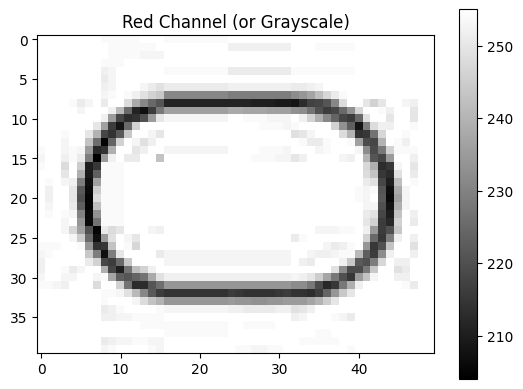

In [10]:
def visualize_output(data):
    print(data.shape)
    red_channel = data[0, :, :]  #data[:, :, 0]# This will have shape (40, 50)
        
    # Alternatively, you can average the 3 channels to convert to grayscale:
    grayscale = data.mean(axis=2)  # This also gives a 2D array of shape (40, 50)

    # Visualize the extracted 2D array (either red channel or grayscale)
    plt.imshow(red_channel, cmap='gray')  # or use grayscale instead of red_channel
    plt.title('Red Channel (or Grayscale)')
    plt.colorbar()
    plt.show()
visualize_output(blank_bubbles[0])

Now we will randomly shuffle the set of blank bubbles and get a subset of 15,000 blank bubbles to later draw synthetic marks on. We will keep track of the index numbers of the subsetted bubbles.

In [11]:
# Shuffle the tensors first (same as before)
num_tensors = blank_bubbles.size(0)

# Generate a random permutation of indices
shuffled_indices = torch.randperm(num_tensors)

# Select the first 25000 indices after shuffling
selected_indices = shuffled_indices[:15000] # record which bubbles these are

# Get the 25000 shuffled tensors
subset_of_blank_bubbles = blank_bubbles[selected_indices]

# Optionally, select corresponding labels if you have filtered_labels
selected_labels = blank_bubbles_labels[selected_indices] if 'filtered_labels' in locals() else None

# Keep track of the selected indices (this tells you which tensors from the original filtered_tensors are selected)
tracked_indices = selected_indices

# Print the shape of selected tensors
print(subset_of_blank_bubbles.shape)  # This should be [25000, 3, 40, 50]

torch.Size([15000, 3, 40, 50])


In [12]:
tracked_indices

tensor([ 4372,  9047,  8252,  ..., 27789, 31145, 11916])

We will now convert the subset of bubbles to grayscale. This uses adapted code from the function `ConvertToGreyScale` in `Busting-The-Ballot/Utilities/VoterLab_Classifier_Functions.py`.

In [13]:
def ConvertTensorToGrayscale(xData):
    newXData = torch.zeros(xData.size(dim = 0), 1, 40, 50)
    # Manually take average of each channel in each image
    # Matlab greyscale conversion formula used: 0.2989 * R + 0.5870 * G + 0.1140 * B
    for i in range(xData.size(dim = 0)):
        newXData[i] = 0.2989 * xData[i][0] + 0.5870 * xData[i][1] + 0.1140 * xData[i][2]
    
    # Return transformed dataloader
    print("Greyscale X-Data Size: ", newXData.size())
    return newXData

In [14]:
grayscale_blank_bubbles = ConvertTensorToGrayscale(subset_of_blank_bubbles)
grayscale_blank_bubbles.shape

Greyscale X-Data Size:  torch.Size([15000, 1, 40, 50])


torch.Size([15000, 1, 40, 50])

In [15]:
grayscale_blank_bubbles[0][0][20]

tensor([212.9787, 230.9769, 250.9749, 254.9745, 253.9746, 254.9745, 254.9745,
        253.9746, 254.9745, 254.9745, 254.9745, 253.9746, 253.9746, 254.9745,
        254.9745, 254.9745, 254.9745, 254.9745, 254.9745, 254.9745, 254.9745,
        254.9745, 254.9745, 254.9745, 254.9745, 254.9745, 254.9745, 254.9745,
        254.9745, 254.9745, 254.9745, 254.9745, 253.9746, 253.9746, 253.9746,
        253.9746, 253.9746, 253.9746, 253.9746, 253.9746, 254.9745, 253.9746,
        250.9749, 251.9748, 254.9745, 254.9745, 246.9753, 232.9767, 212.5874,
        232.5854])

In [16]:
grayscale_blank_bubbles[50][0].shape

torch.Size([40, 50])

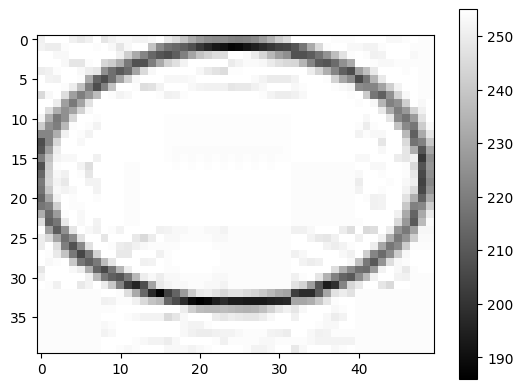

In [17]:
plt.imshow(grayscale_blank_bubbles[0][0], cmap='gray')  # or use grayscale instead of red_channel
# plt.title('Red Channel (or Grayscale)')
plt.colorbar()
plt.show()

Finally we will now save the subset of 15,000 grayscale blank bubbles and their index labels into a Torch object for further use.

In [18]:
torch.save((grayscale_blank_bubbles,tracked_indices), 'blank_bubbles.pth')

In [19]:
# testing the output of the saved Torch object
loaded_tensor = torch.load('blank_bubbles.pth')

In [20]:
loaded_tensor[0].shape

torch.Size([15000, 1, 40, 50])

In [21]:
loaded_tensor[1].shape

torch.Size([15000])